In [1]:
!pip install -q torch torchvision opencv-python tqdm seaborn
!pip install joblib

100%|██████████| 2000/2000 [02:38<00:00, 12.60it/s]


Highest Correlation Score: 0.7583326424674491
Sample Index: 175


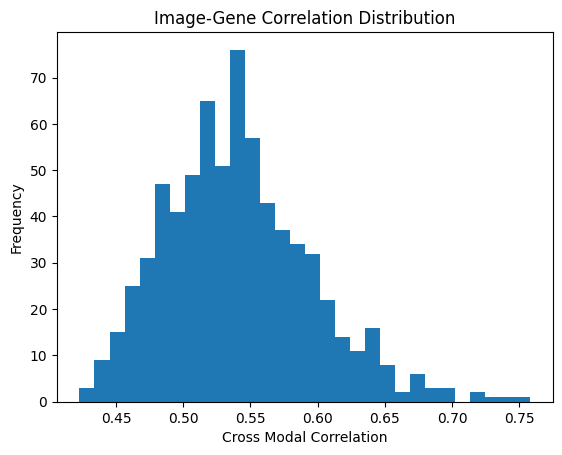

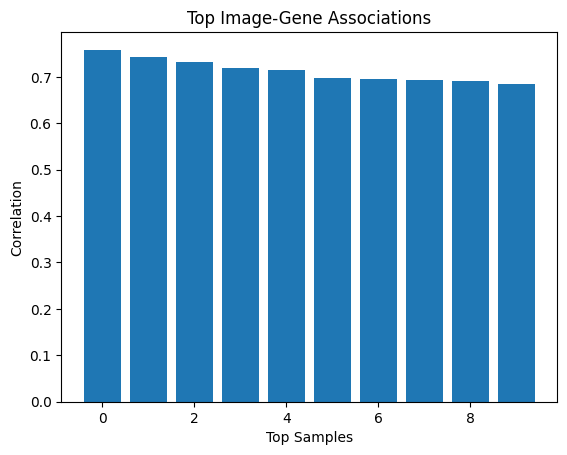

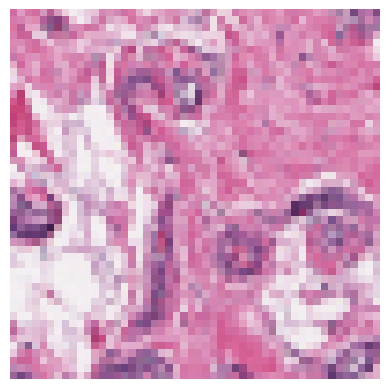

     Sample  Correlation
175     175     0.758333
18       18     0.742539
428     428     0.731621
542     542     0.718787
398     398     0.714341
39       39     0.697306
681     681     0.696187
492     492     0.693331
148     148     0.691127
183     183     0.685230


In [2]:
import os
import numpy as np
import pandas as pd
import cv2
import torch
from torchvision import models, transforms
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from tqdm import tqdm

gene_path="/kaggle/input/datasets/samdemharter/brca-multiomics-tcga/data.csv"
gene_data=pd.read_csv(gene_path)
gene_data=gene_data.set_index(gene_data.columns[0])

scaler=StandardScaler()
gene_scaled=scaler.fit_transform(gene_data)

pca_gene=PCA(n_components=30)
gene_embed=pca_gene.fit_transform(gene_scaled)

base="/kaggle/input/datasets/paultimothymooney/breast-histopathology-images/IDC_regular_ps50_idx5"

image_paths=[]
for patient in os.listdir(base):
    p=os.path.join(base,patient)
    if os.path.isdir(p):
        for label in os.listdir(p):
            l=os.path.join(p,label)
            if os.path.isdir(l):
                for img in os.listdir(l):
                    if img.endswith(".png"):
                        image_paths.append(os.path.join(l,img))

transform=transforms.Compose([
transforms.ToPILImage(),
transforms.Resize((224,224)),
transforms.ToTensor()
])

cnn=models.resnet50(weights="IMAGENET1K_V1")
cnn=torch.nn.Sequential(*list(cnn.children())[:-1])
cnn.eval()

img_features=[]

for img_path in tqdm(image_paths[:2000]):
    img=cv2.imread(img_path)
    if img is None:
        continue
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    img=transform(img).unsqueeze(0)
    with torch.no_grad():
        f=cnn(img)
    img_features.append(f.squeeze().numpy())

img_features=np.array(img_features)

pca_img=PCA(n_components=30)
img_embed=pca_img.fit_transform(img_features)

min_samples=min(len(img_embed),len(gene_embed))

X=img_embed[:min_samples]
Y=gene_embed[:min_samples]

scalerX=StandardScaler()
scalerY=StandardScaler()

X=scalerX.fit_transform(X)
Y=scalerY.fit_transform(Y)

sim_matrix=cosine_similarity(X,Y)

max_corr=np.max(sim_matrix,axis=1)
# Find index of highest correlation
best_sample_idx = np.argmax(max_corr)

print("Highest Correlation Score:", max_corr[best_sample_idx])
print("Sample Index:", best_sample_idx)

corr_df=pd.DataFrame({
"Sample":range(len(max_corr)),
"Correlation":max_corr
})

plt.hist(corr_df["Correlation"],bins=30)
plt.xlabel("Cross Modal Correlation")
plt.ylabel("Frequency")
plt.title("Image-Gene Correlation Distribution")
plt.show()

top_corr=corr_df.sort_values("Correlation",ascending=False).head(10)

plt.bar(range(len(top_corr)),top_corr["Correlation"])
plt.xlabel("Top Samples")
plt.ylabel("Correlation")
plt.title("Top Image-Gene Associations")
plt.show()

img=cv2.imread(image_paths[0])
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

print(top_corr)

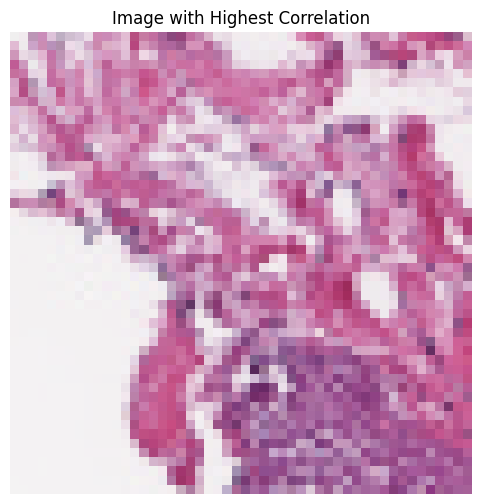

Associated Gene Profile:
rs_CPB1         3.741305
rs_SCGB2A2     17.701443
rs_SCGB1D2     13.127492
rs_TFF1        13.665711
rs_MUCL1        7.810392
rs_GSTM1        2.554442
rs_PIP         11.193884
rs_ADIPOQ       8.434449
rs_ADH1B        8.242399
rs_S100A7       0.807272
rs_HMGCS2      13.360427
rs_CYP2B7P1    14.404604
rs_ANKRD30A     9.229240
rs_PRAME        0.807272
rs_TAT          6.268949
rs_SERPINA6     0.459432
rs_AGR3        12.296306
rs_TFAP2B      10.926208
rs_CYP4Z1      14.241421
rs_DHRS2       10.204849
Name: 12.3077675847136, dtype: float64

Top Influential Genes:
rs_SCGB2A2     17.701443
rs_SCUBE2      15.135779
rs_GFRA1       14.483966
rs_CYP2B7P1    14.404604
rs_ESR1        14.252965
rs_CYP4Z1      14.241421
rs_LTF         14.228742
rs_WFDC2       14.228432
rs_TFF1        13.665711
rs_HMGCS2      13.360427
Name: 12.3077675847136, dtype: float64


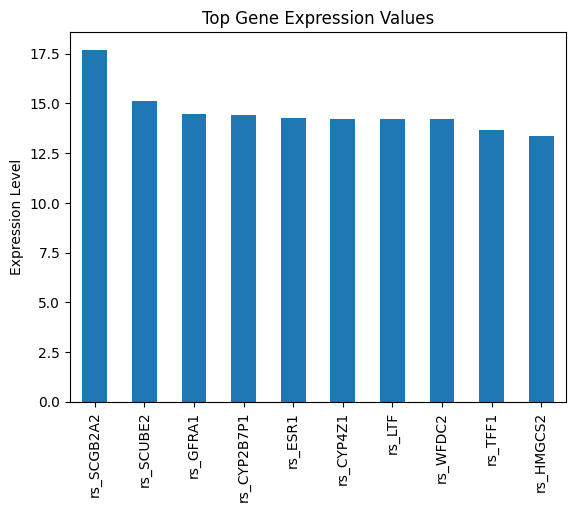

In [3]:
best_image_path = image_paths[best_sample_idx]

img = cv2.imread(best_image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Image with Highest Correlation")
plt.axis("off")
plt.show()
best_gene_profile = gene_data.iloc[best_sample_idx]

print("Associated Gene Profile:")
print(best_gene_profile.head(20))  # show first 20 genes
top_genes = best_gene_profile.abs().sort_values(ascending=False).head(10)

print("\nTop Influential Genes:")
print(top_genes)
top_genes.plot(kind="bar")

plt.title("Top Gene Expression Values")
plt.ylabel("Expression Level")
plt.show()

In [4]:

import joblib

joblib.dump(gene_embed,"gene_embeddings.pkl")
joblib.dump(gene_data,"gene_data.pkl")

joblib.dump(pca_img,"pca_img.pkl")
joblib.dump(pca_gene,"pca_gene.pkl")

joblib.dump(scalerX,"scalerX.pkl")
joblib.dump(scalerY,"scalerY.pkl")


print("Models saved successfully")

Models saved successfully


In [8]:
gene_data.iloc[0].to_csv("sample_gene_patient.csv",index=False)
print("file ready")

best_gene_profile.to_csv("sample_gene_patient1.csv", index=False)

print("Gene file saved")
best_sample_idx = np.argmax(max_corr)

print(best_sample_idx)
print(max_corr[best_sample_idx])

gene_data.iloc[[best_sample_idx]].to_csv(
    "demo_gene_sample.csv",
    index=False
)

print(image_paths[best_sample_idx])

file ready
Gene file saved
175
0.7583326424674491
/kaggle/input/datasets/paultimothymooney/breast-histopathology-images/IDC_regular_ps50_idx5/10295/0/10295_idx5_x1101_y2051_class0.png
